# CubeSat Geometry Walkthrough

This notebook is a stepwise check of the new `geometry/CubeSat/` layer.

What it does:
- builds the default 6U double-deployable CubeSat example
- realizes the body-fixed geometry from deployment angles
- prints a compact surface summary
- plots the realized surfaces in 3D
- lets you try custom deployment states
- shows a simple ray-intersection check for future occlusion work

Run the cells from top to bottom.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from geometry import build_6u_double_deployable


In [2]:
def _set_axes_equal(ax):
    x_limits = np.array(ax.get_xlim3d())
    y_limits = np.array(ax.get_ylim3d())
    z_limits = np.array(ax.get_zlim3d())

    spans = np.array([
        x_limits[1] - x_limits[0],
        y_limits[1] - y_limits[0],
        z_limits[1] - z_limits[0],
    ])
    centers = np.array([
        x_limits.mean(),
        y_limits.mean(),
        z_limits.mean(),
    ])
    radius = 0.5 * max(spans.max(), 1e-6)

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


def print_surface_summary(realized):
    header = f"{'name':24s} {'center [m]':30s} {'normal':24s} {'size [m]':18s} tags"
    print(header)
    print('-' * len(header))
    for surface in realized.surfaces:
        center = tuple(np.round(surface.center, 4))
        normal = tuple(np.round(surface.normal, 4))
        size = f"{surface.width:.4f} x {surface.height:.4f}"
        tags = ', '.join(surface.tags)
        print(f"{surface.name:24s} {str(center):30s} {str(normal):24s} {size:18s} {tags}")


def plot_realized_geometry(realized, *, title='CubeSat geometry', normal_scale=0.04):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for surface in realized.surfaces:
        if 'solar_panel' in surface.tags:
            color = '#5B8FF9'
        elif 'bus' in surface.tags:
            color = '#C7C7C7'
        else:
            color = '#8C8C8C'

        corners = surface.corners()
        poly = Poly3DCollection([corners], facecolors=color, edgecolors='black', alpha=0.70)
        ax.add_collection3d(poly)

        center = surface.center
        normal = surface.normal
        ax.quiver(
            center[0], center[1], center[2],
            normal[0], normal[1], normal[2],
            length=normal_scale,
            color='crimson',
            linewidth=1.2,
        )
        ax.text(center[0], center[1], center[2], surface.name, fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('body x [m]')
    ax.set_ylabel('body y [m]')
    ax.set_zlabel('body z [m]')
    ax.view_init(elev=22, azim=-58)
    _set_axes_equal(ax)
    plt.tight_layout()
    return fig, ax


## Step 1: Build the default 6U example

Edit `leaf_y` and `leaf_z` in the next cell to change the size of each deployable panel leaf.

In [3]:
leaf_y = 0.2263  # panel-leaf dimension along body y [m]
leaf_z = 0.3405  # panel-leaf dimension along body z [m]

cubesat = build_6u_double_deployable(leaf_y=leaf_y, leaf_z=leaf_z)

print('metadata:', cubesat.metadata)
print('default state keys:')
for key, value in cubesat.default_state().items():
    print(f'  {key}: {math.degrees(value):.1f} deg')


metadata: {'example': '6U_double_deployable', 'bus_dimensions_m': (0.1, 0.2263, 0.3405), 'leaf_y_m': 0.2263, 'leaf_z_m': 0.3405, 'leaf_dimensions_m': (0.2263, 0.3405), 'wing_span_m': 0.2263, 'wing_length_m': 0.3405}
default state keys:
  wing_port_inner_angle: 90.0 deg
  wing_port_outer_angle: 180.0 deg
  wing_starboard_inner_angle: -90.0 deg
  wing_starboard_outer_angle: -180.0 deg


## Step 2: Realize the default deployed geometry

In [4]:
realized_default = cubesat.realize()

print('surface count:', len(realized_default.surfaces))
print('solar panels:', [surface.name for surface in realized_default.by_tag('solar_panel')])
print()
print_surface_summary(realized_default)


surface count: 10
solar panels: ['wing_port_inner', 'wing_port_outer', 'wing_starboard_inner', 'wing_starboard_outer']

name                     center [m]                     normal                   size [m]           tags
--------------------------------------------------------------------------------------------------------
bus_+X                   (0.05, 0.0, 0.0)               (1.0, 0.0, 0.0)          0.3405 x 0.2263    bus, +X
bus_-X                   (-0.05, 0.0, 0.0)              (-1.0, 0.0, 0.0)         0.3405 x 0.2263    bus, -X
bus_+Y                   (0.0, 0.1132, 0.0)             (0.0, 1.0, 0.0)          0.3405 x 0.1000    bus, +Y
bus_-Y                   (0.0, -0.1132, 0.0)            (0.0, -1.0, 0.0)         0.3405 x 0.1000    bus, -Y
bus_+Z                   (0.0, 0.0, 0.1703)             (0.0, 0.0, 1.0)          0.1000 x 0.2263    bus, +Z
bus_-Z                   (0.0, 0.0, -0.1703)            (0.0, 0.0, -1.0)         0.1000 x 0.2263    bus, -Z
wing_port_inner       

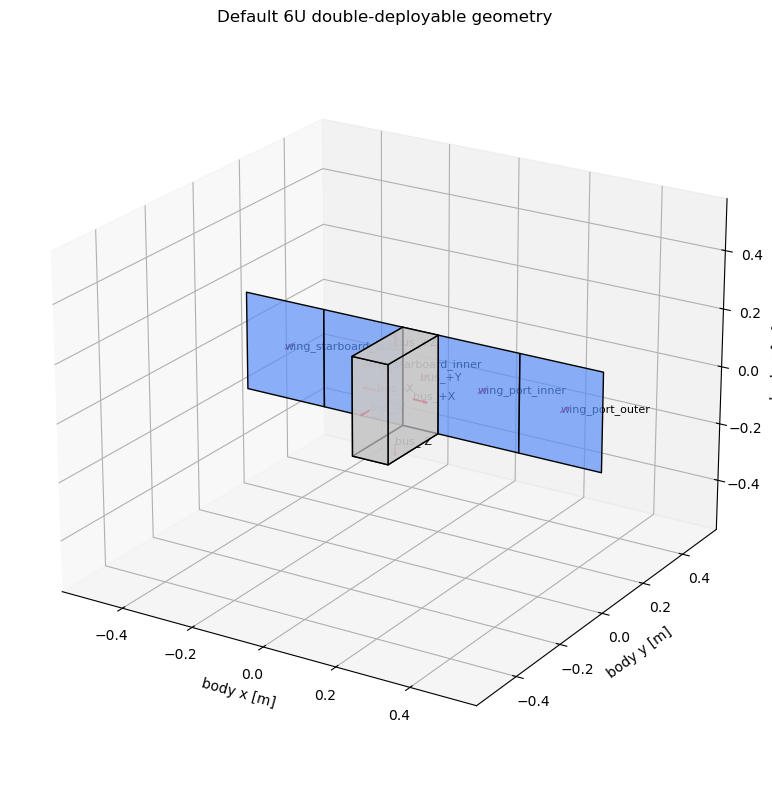

In [5]:
plot_realized_geometry(realized_default, title='Default 6U double-deployable geometry')
plt.show()


## Step 3: Try a custom deployment state

Edit the angles below and rerun the cell.

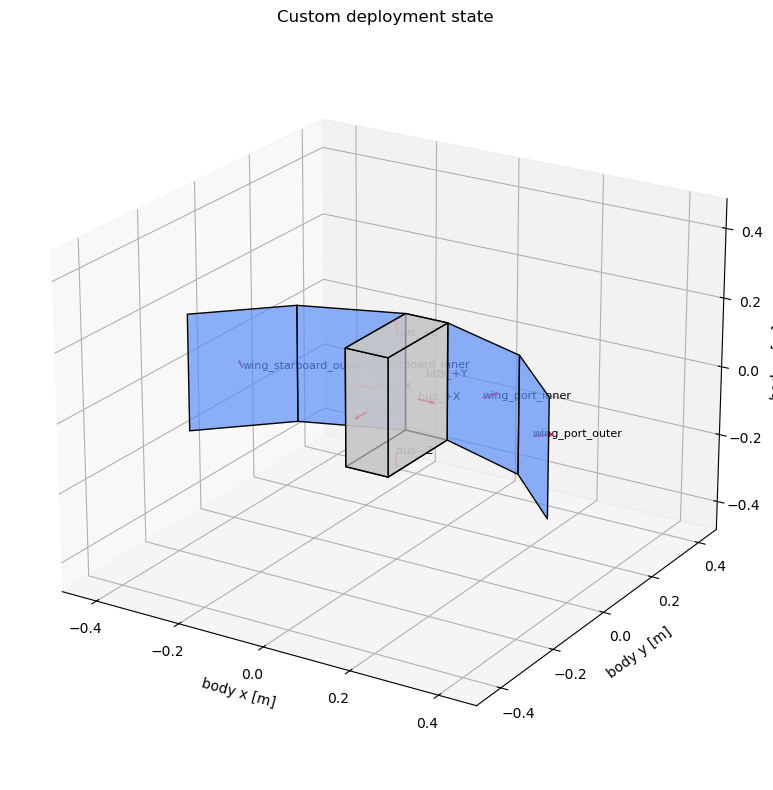

In [6]:
state_demo = {
    'wing_port_inner_angle': math.radians(70.0),
    'wing_port_outer_angle': math.radians(155.0),
    'wing_starboard_inner_angle': math.radians(-70.0),
    'wing_starboard_outer_angle': math.radians(-155.0),
}

realized_demo = cubesat.realize(state_demo)
plot_realized_geometry(realized_demo, title='Custom deployment state')
plt.show()


## Step 4: Simple ray-intersection check

This is not yet the full occlusion engine. It just confirms the geometry object can answer nearest-hit rectangle queries, which is the next thing the view-factor layer will use.

In [7]:
bus_face = realized_default.by_name('bus_+Y')
origin = bus_face.center + 1e-4 * bus_face.normal
direction = bus_face.normal

hit = realized_default.first_intersection(origin, direction, exclude=('bus_+Y',))
print('ray origin    :', np.round(origin, 6))
print('ray direction :', np.round(direction, 6))
print('first hit     :', None if hit is None else (hit[0].name, round(hit[1], 6)))


ray origin    : [0.      0.11325 0.     ]
ray direction : [0. 1. 0.]
first hit     : None
